## Download the dataset

For the project use the Heart Failure Prediction dataset from Kaggle:
https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction/data

The goal is train a classifier model to predcit HeartDisease values.

In [2]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("data")
if not DATA_DIR.exists():
    DATA_DIR = Path("ch03_classification/data")

def load_heart_data():
  csv_path = DATA_DIR / "heart.csv"
  if not csv_path.is_file():
    raise FileNotFoundError(csv_path)

  df = pd.read_csv(csv_path)
  return df

## Check how the data looks

Attribute Information (copied from Kaggle)
- Age: age of the patient [years]
- Sex: sex of the patient [M: Male, F: Female]
- ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
- RestingBP: resting blood pressure [mm Hg]
- Cholesterol: serum cholesterol [mm/dl]
- FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
- RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
- MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]
- ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
- Oldpeak: oldpeak = ST [Numeric value measured in depression]
- ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
- HeartDisease: output class [1: heart disease, 0: Normal]

In [3]:
from sklearn.model_selection import train_test_split

heart_full = load_heart_data()

train_set, test_set = train_test_split(heart_full, test_size=0.2, random_state=42)

Get an overview on what the data actually looks like

In [4]:
train_set.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
795,42,M,NAP,120,240,1,Normal,194,N,0.8,Down,0
25,36,M,NAP,130,209,0,Normal,178,N,0.0,Up,0
84,56,M,ASY,150,213,1,Normal,125,Y,1.0,Flat,1
10,37,F,NAP,130,211,0,Normal,142,N,0.0,Up,0
344,51,M,ASY,120,0,1,Normal,104,N,0.0,Flat,1


Check for any missing values that might need handling

In [5]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 734 entries, 795 to 102
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             734 non-null    int64  
 1   Sex             734 non-null    str    
 2   ChestPainType   734 non-null    str    
 3   RestingBP       734 non-null    int64  
 4   Cholesterol     734 non-null    int64  
 5   FastingBS       734 non-null    int64  
 6   RestingECG      734 non-null    str    
 7   MaxHR           734 non-null    int64  
 8   ExerciseAngina  734 non-null    str    
 9   Oldpeak         734 non-null    float64
 10  ST_Slope        734 non-null    str    
 11  HeartDisease    734 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 74.5 KB


No missing values. Next lets check the numeric attributes.

In [6]:
train_set.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000
mean,53.651226,133.064033,199.683924,0.227520,136.178474,0.905041,0.546322
std,9.364290,18.438941,108.216855,0.419517,25.329254,1.082952,0.498189
min,29.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,177.000000,0.000000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,269.000000,0.000000,155.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


At least RestingBP and Cholesterol have min values on 0, which should not be possible if the person is alive.

In [7]:
print("RestingBP zeroes:", sum(train_set["RestingBP"] == 0))
print("Cholesterol zeroes:", sum(train_set["Cholesterol"] == 0))

RestingBP zeroes: 1
Cholesterol zeroes: 137


In [8]:
train_set["HeartDisease"].value_counts()

HeartDisease
1    401
0    333
Name: count, dtype: int64

And get a look into some of the categorial attributes

In [9]:
train_set["ChestPainType"].value_counts()

ChestPainType
ASY    401
NAP    162
ATA    139
TA      32
Name: count, dtype: int64

In [10]:
train_set["RestingECG"].value_counts()

RestingECG
Normal    444
LVH       149
ST        141
Name: count, dtype: int64

In [11]:
train_set["ST_Slope"].value_counts()

ST_Slope
Flat    379
Up      307
Down     48
Name: count, dtype: int64

## Build data processing pipelines

In [12]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer

# Pipeline for numeric features. There were no missing values in the train set, 
# but test / real data might have, so impute missing values with medians,
# and then apply standard scaling.
num_pipeline = Pipeline([
  ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
  ("scaler", StandardScaler())
])

# Pipeline for those impossible zero cases (RestingBP and Cholesterol). 
# Turn the zeroes into NaNs, so that the imputer handles them correctly as missing data
num_pipeline_non_valid_zeros = Pipeline([
  ("zero_to_nan", FunctionTransformer(lambda X: np.where(X == 0, np.nan, X))),
  ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
  ("scaler", StandardScaler())
])

# For categorial features, first turn the values into numbers with the OrdinalEncoder,
# next impute any missing entries with most frequent value, and finally one-hot encode the values
cat_pipeline = Pipeline([
  ("ordinal_encoder", OrdinalEncoder()),
  ("imputer", SimpleImputer(strategy="most_frequent")),
  ("cat_encoder", OneHotEncoder(sparse_output=False))
])

Sidenote: Replacing the impossible zeros in Cholesterol/RestingBP with NaN initially dropped recall, precision and F1 score down, the zeros were informative (correlated with positive cases). Adding add_indicator=True to the imputer preserved that "missing" signal as its own feature.


Compose the pipelines into one preprocessing pipeline.

In [13]:
from sklearn.compose import ColumnTransformer

num_features = ["Age", "FastingBS", "MaxHR", "Oldpeak"]
num_features_non_valid_zeros = ["RestingBP", "Cholesterol"]
cat_features = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

preprocessing = ColumnTransformer([
  ("num", num_pipeline, num_features),
  ("num_non_valid_zeros", num_pipeline_non_valid_zeros, num_features_non_valid_zeros),
  ("cat", cat_pipeline, cat_features),
])

In [14]:
X_train = preprocessing.fit_transform(train_set)
y_train = train_set["HeartDisease"] # Get the labels!

In [15]:
X_train

array([[-1.24506731,  1.84260945,  2.28435288, ...,  1.        ,
         0.        ,  0.        ],
       [-1.8862362 , -0.5427086 ,  1.65224147, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.25099346,  1.84260945, -0.44162756, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 0.67843939, -0.5427086 ,  0.30900473, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.67843939, -0.5427086 , -0.7181763 , ...,  0.        ,
         0.        ,  1.        ],
       [-1.45879027, -0.5427086 , -0.24409275, ...,  0.        ,
         1.        ,  0.        ]], shape=(734, 22))

The output from the pipeline looks to be correct.

Verify that the pipeline handled the non-valid zeros correctly

In [16]:
print("RestingBP NaNs:", train_set["RestingBP"].isna().sum())
print("Cholesterol NaNs:", train_set["Cholesterol"].isna().sum())

RestingBP NaNs: 0
Cholesterol NaNs: 0


## Train a classifier model

Lets start simple, test out the SGDClassifier and see what it gives us.

In [17]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)


,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


Run cross_val_predict to get predictions made on the folds test sets

In [18]:
from sklearn.model_selection import cross_val_predict

y_train_predicts = cross_val_predict(sgd_clf, X_train, y_train, cv=3)

Check the confusion matrix to see how the negative/positive classes are distributed

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train, y_train_predicts)
cm

array([[264,  69],
       [ 43, 358]])

Next check how precision and recall compare

Note:
Precision/Recall tradeoff

If you increase precision, you lower recall -> you will miss more actual positives when you start increasing the threshol

If you increase recall, you lower precision -> you will get more false positives as you lower the threshold

In [20]:
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score

# Out of all the positive predictions, how many were actually correct
precision_score(y_train, y_train_predicts)

0.8384074941451991

In [21]:
# Out of the positive cases, how many did the model pick up.
recall_score(y_train, y_train_predicts)

0.8927680798004988

In [22]:
f1_score(y_train, y_train_predicts)

0.8647342995169082

Check the precision/recall curve

In [23]:
from sklearn.metrics import precision_recall_curve

y_scores = cross_val_predict(sgd_clf, X_train, y_train, cv=3, method="decision_function")

precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)

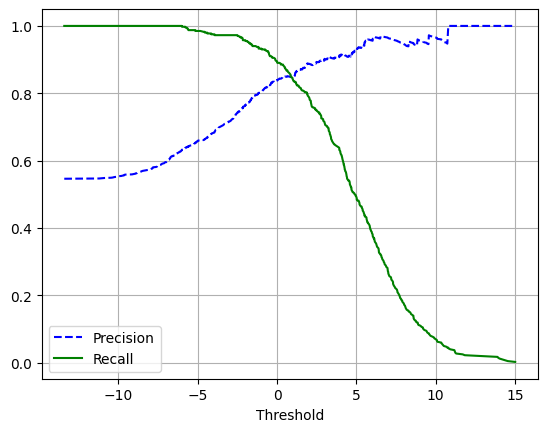

In [24]:
import matplotlib.pyplot as plt

plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.grid(True)
plt.show()


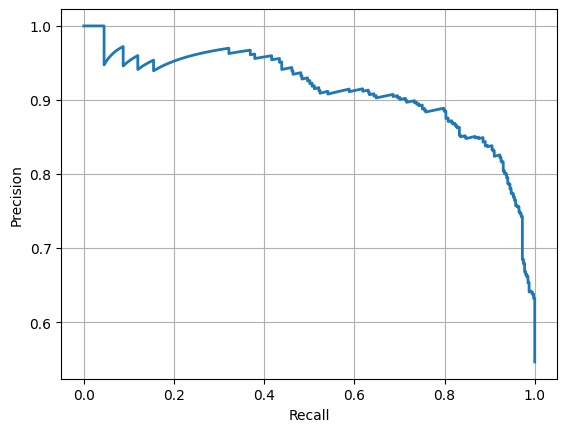

In [25]:
plt.plot(recalls, precisions, linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()


Since we are predicting heart diseases target 0.9 recall. That way we will miss less actual positives.

In [26]:
idx_for_90_recall = (recalls >= 0.90).argmin() - 1   # last threshold with recall >= 0.90
threshold_90 = thresholds[idx_for_90_recall]
threshold_90


np.float64(-0.10561807424525993)

In [27]:
# Predictions that are equal or greater than our 90 recall threshold
y_train_pred_90 = (y_scores >= threshold_90)

Check what precision we get when the recall is >= 0.90

In [28]:
precision_score(y_train, y_train_pred_90)

0.8375870069605569

In [29]:
recall_at_90 = recall_score(y_train, y_train_pred_90)
recall_at_90

0.9002493765586035

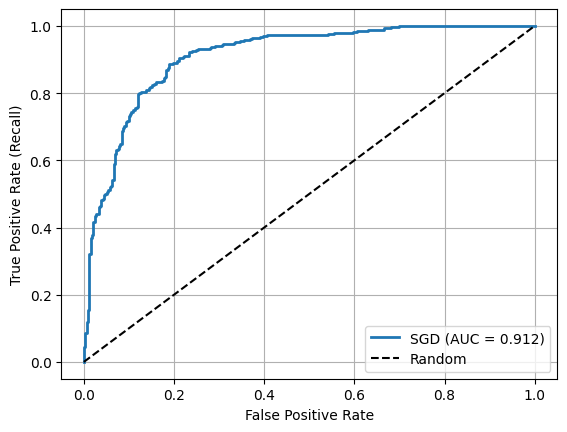

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_train, y_scores)
auc = roc_auc_score(y_train, y_scores)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr, linewidth=2, label=f"SGD (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.legend()
plt.grid(True)
plt.show()
